# A certificate for the unroll depth

The [fixpoints notebook](fixpoints.ipynb) left one asymmetry: a *lossy* loop
knows its depth in advance through `unroll_depth`, but a lossless loop has no
guarantee at all — `fix` warns that nothing certifies its `max_steps`. The
stationary boson sampling bound closes that gap. For a feedback
interferometer $U$ on $L + M$ modes — $L$ loop wires, its last ones, and $M$
external wires where photons enter and detectors sit — write
$U_{ll} = U[-L{:}, -L{:}]$ for the loop block and
$\beta_1 \ge \dots \ge \beta_L$ for the singular values of $U_{ll}^k$.
The claim is

$$\big\|\rho_{stat} - \rho^{(k)}\big\|_1
\;\le\; 4K(\bar q)\sum_{r=1}^L \arcsin^2\beta_r,
\qquad K(\bar q) = (\bar q+1)\Big[\sqrt{6\bar q(\bar q+1)} + \bar q\Big]$$

where $\rho^{(k)}$ is the loop state after $k$ round trips, $\rho_{stat}$
its fixpoint and $\bar q$ the largest photon number injected per mode. What
makes it strong is what the constant does *not* depend on: the depth, the
total photon number, the Fock cutoff, and any non-normality of $U_{ll}$ —
summing the $L$ singular directions instead of taking the worst one is what
kills the unboundable constant $C_U$ of $\|U_{ll}^k\| \le C_U\rho^k$.
`unroll_certificate` implements the resulting stopping rule: the smallest
$k$ whose bound falls below `tol`, exact in $O(kL^3)$, no eigenvalue and no
loss required. This notebook checks the claim against optyx's actual
unrolled loop states, then races the certificate against `unroll_depth`.

In [1]:
import numpy as np

from optyx import photonic
from optyx.channel import (
    Diagram, Discard, qmode, unroll_certificate)


def loop_over(unitary, injected=1):
    """The closed feedback loop of `unitary`: fresh photons in the first
    modes, every detector output discarded, the last mode fed back."""
    size = len(unitary)
    return (photonic.Create(*[injected] * (size - 1)) @ qmode
            >> photonic.Gate(np.asarray(unitary), size, size, "U")
            >> Discard(qmode ** (size - 1)) @ qmode
            ).feedback(mem=qmode, state=photonic.Create(0))


def loop_state(loop, steps):
    """The loop state after `steps` round trips, as a density matrix:
    unroll with the final memory left open and evaluate."""
    return loop.unroll_with_boundaries(
        steps - 1, effect=None).eval().density_matrix


def trace_norm(left, right):
    size = max(left.shape[0], right.shape[0])
    padded = [np.pad(x, [(0, size - x.shape[0])] * 2)
              for x in (left, right)]
    return np.abs(np.linalg.eigvalsh(padded[0] - padded[1])).sum()


K_ONE_PHOTON = 2 * (np.sqrt(12) + 1)

## Checking the claim

A two-mode loop whose block keeps an amplitude $\beta = 0.3$ per round
trip: the bound says the distance to the fixpoint decays as
$\arcsin^2(\beta^k) \approx \beta^{2k}$ — second order in the block, not
first, because photon-number conservation kills the odd orders. We unroll
the loop for real, take trace distances to a deep unrolling, and put the
bound next to them.

In [2]:
beta = 0.3
angle = np.arccos(beta)
unitary = np.array([[np.cos(angle), -np.sin(angle)],
                    [np.sin(angle), np.cos(angle)]])
loop = loop_over(unitary)
settled = loop_state(loop, 9)
print("  k   distance        bound      ratio")
for steps in range(1, 6):
    bound = 4 * K_ONE_PHOTON * np.arcsin(beta ** steps) ** 2
    distance = trace_norm(settled, loop_state(loop, steps))
    print(f"  {steps}   {distance:.3e}   {bound:.3e}   {bound/distance:6.1f}")

  k   distance        bound      ratio
  1   4.587e-01   3.315e+00      7.2
  2   2.627e-02   2.901e-01     11.0
  3   2.298e-03   2.604e-02     11.3


  4   2.063e-04   2.343e-03     11.4
  5   1.856e-05   2.109e-04     11.4


The bound dominates at every depth and tracks the true decay rate
$\beta^2 = 0.09$ per step exactly — the slack is a constant factor, not a
different exponent. That constant is the price of a bound that holds for
*any* reachable pair of states, uniformly in everything but $\bar q$.

## The unitarity floor

Light can only leave the loop through the $M$ external wires, so
$\|U_{ll}^k\| = 1$ exactly for every $k \le \lceil L/M\rceil - 1$,
whatever the unitary: no certificate can be shorter than
$\lceil L/M\rceil$. With three loop modes draining through one external
wire, the first two powers of the block are perfect isometries on some
direction — and the certificate respects the floor without being told.

In [3]:
def haar(size, seed):
    rng = np.random.default_rng(seed)
    z = rng.normal(size=(size, size)) + 1j * rng.normal(size=(size, size))
    q, r = np.linalg.qr(z)
    return q * (np.diag(r) / np.abs(np.diag(r)))


wide = haar(4, seed=7)
block = wide[-3:, -3:]
print("norms of the block powers:", [
    round(np.linalg.norm(np.linalg.matrix_power(block, k), 2), 6)
    for k in (1, 2, 3)])
print("certificate:", unroll_certificate(wide, loop_modes=3, tol=1e-3))

norms of the block powers: [1.0, 1.0, 0.963518]
certificate: 126


## The delay line reaches its fixpoint in one step

The embedding of ordinary boson sampling: $U = \mathrm{SWAP}\cdot
(W \oplus \mathrm{Id}_L)$ turns any single-pass circuit $W$ into a
feedback one whose loop is a pure delay. The loop block vanishes, so the
certificate is a single round trip — the reduction is exact and no mixing
time enters.

In [4]:
phase = np.exp(2j * np.pi * 0.3)
delay_line = np.array([[0, 1], [1, 0]]) @ np.diag([phase, 1])
print("loop block:", delay_line[-1:, -1:].item())
print("certificate:", unroll_certificate(delay_line, loop_modes=1))

loop block: 0j
certificate: 1


## Against `unroll_depth`

`unroll_depth` sees only the loss: $n^\star = \lceil\log(tol)/
\log(1-loss)\rceil$, and it refuses a lossless loop outright. The
certificate sees the geometry, and a loss just damps every singular value
by $\sqrt{1-loss}$ per round trip — the two agree up to the constant
$4K(\bar q)$ of the bound, and the certificate keeps working when the
loss is zero.

In [5]:
reflective = np.array([[.6, .8], [.8, -.6]])
loop = loop_over(reflective)
print("loss  unroll_depth  certificate")
for loss in (0, .5, .9):
    depth = (loop.unroll_depth(1e-6, loss) if loss else "refused")
    certificate = unroll_certificate(
        reflective, loop_modes=1, tol=1e-6, loss=loss)
    print(f" {loss:.1f}  {str(depth):>12}  {certificate:11}")

loss  unroll_depth  certificate
 0.0       refused           18
 0.5            20           11
 0.9             6            6


## The certificate closes `fix`'s warning

`fix(max_steps=...)` warns that no loss certifies its depth — the
certificate is exactly the number that discharges that warning by hand.
Contract at the certified depth and the result agrees with the
eigensolve to the tolerance the bound promised.

In [6]:
import warnings

certified = unroll_certificate(unitary, loop_modes=1, tol=1e-6)
measured = (photonic.Create(1) @ qmode
            >> photonic.Gate(unitary, 2, 2, "U")
            >> photonic.NumberResolvingMeasurement(1) @ qmode
            ).feedback(mem=qmode, state=photonic.Create(0))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    contracted = measured.fix(chi=None, max_steps=certified)
stationary = measured.eigen_fix()
disagreement = max(
    abs(contracted.prob_dist().get(k, 0) - v)
    for k, v in stationary.prob_dist().items())
print(f"certified depth: {certified}")
print(f"fix vs eigen_fix at that depth: {disagreement:.2e}")

certified depth: 8
fix vs eigen_fix at that depth: 3.94e-08


## Further reading

The bound and its proof are A. Lesage, *Stationary Boson Sampling* (2026),
internal notes, §2 — the second-order argument is §3.3–§3.7 of the full
manuscript. The setup and the eigensolve it certifies are Yu. A. Biriukov
and I. V. Dyakonov, [Simulation of boson sampling with optical
feedback](https://doi.org/10.48550/arXiv.2602.05566), arXiv:2602.05566
(2026); the complexity consequence — the looped architecture stays inside
boson sampling, Haar-typically and unconditionally under loss — is §3 of
the notes.

## Complexity, and how fast the bound converges

The certificate is a linear scan: at step $k$ one matrix product updates
$U_{ll}^k$ and one SVD reads its singular values, both $O(L^3)$ — the only
hard part *is* the singular values, and they are computed at every $k$
until the bound clears the tolerance, never from scratch and never via an
eigendecomposition. So the cost is $O(L^3)$ *per round trip certified*,
and the total cost is decided by the answer to the scaling question below
— it cannot be stated non-circularly before measuring how the certified
depth itself grows. How fast the bound falls is set by the block: after
the transient allowed by the floor, $\sum_r \arcsin^2\beta_r$ decays at
the second order of the largest singular value.

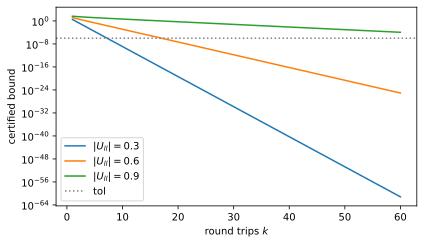

In [7]:
import gc

import matplotlib.pyplot as plt

del contracted, stationary, settled
gc.collect()

figure, axis = plt.subplots(figsize=(6, 3.5))
steps = np.arange(1, 61)
for norm in (.3, .6, .9):
    bounds = [4 * K_ONE_PHOTON * np.arcsin(norm ** k) ** 2 for k in steps]
    axis.semilogy(steps, bounds, label=f"$|U_{{ll}}| = {norm}$")
axis.axhline(1e-6, color="gray", linestyle=":", label="tol")
axis.set_xlabel("round trips $k$")
axis.set_ylabel("certified bound")
axis.legend()
plt.tight_layout()
plt.show()

## Veridicity: random interferometers at the certified depth

The claim, tested on random draws — haar externals around a beam splitter
whose transmissivity sets the loop block. Unrolling to the certified depth
as a tensor network is exactly the cost the certificate exists to license
skipping, so the loop state $\rho^{(k)}$ is iterated on the transfer
matrix built from optyx's own one-step tensors: $k$ matrix products, a
trace that must stay at one for the truncation to have been harmless.

Two checks, matching where each reference is computable. Where the
retention is weak, `eigen_fix` accepts the loop and the certified state
must agree with it to the promised tolerance — the trace-norm claim
implies the distribution check, since measuring is a channel and trace
distance only shrinks under channels. Where the retention is strong,
`eigen_fix` refuses (its truncation test is worst-case over inputs, and a
strongly-retaining loop loses trace at every uniform cutoff), and the
bound's own Cauchy form takes over:
$\|\rho^{(k+m)} - \rho^{(k)}\|_1 \le 4K(\bar q)\Theta_k$ uniformly
in $m$ — the very inequality whose limit defines $\rho_{stat}$.

In [8]:
from discopy import tensor as discopy_tensor

from optyx.core import diagram as core_diagram
from optyx.core.backends import EvalResult, StateType


def drawn_interferometer(transmissivity, seed):
    """Haar externals around a beam splitter: the loop block has norm
    exactly sqrt(1 - transmissivity ** 2)."""
    mixing = np.eye(3, dtype=complex)
    leak = np.sqrt(1 - transmissivity ** 2)
    mixing[1:, 1:] = [[leak, transmissivity], [transmissivity, -leak]]
    entering = np.eye(3, dtype=complex)
    entering[:2, :2] = haar(2, seed)
    leaving = np.eye(3, dtype=complex)
    leaving[:2, :2] = haar(2, seed + 100)
    return leaving @ mixing @ entering


def observed_loop(unitary):
    return (photonic.Create(1, 0) @ qmode
            >> photonic.Gate(unitary, 3, 3, "U")
            >> photonic.NumberResolvingMeasurement(1)
            @ Discard(qmode) @ qmode
            ).feedback(mem=qmode, state=photonic.Create(0))


def transfer_pieces(loop, cutoff):
    """The transfer matrix, trace functional and readout tensor of one
    step, truncated at `cutoff` — the same split `eigen_fix` uses."""
    step = loop.one_step()
    memory = step.cod[len(loop.cod):]
    dims = [cutoff] * len(memory.double())
    truncated = (step >> Discard(loop.cod) @ Diagram.id(memory)
                 ).double().to_tensor(dims)
    operator = (truncated >> discopy_tensor.Diagram.tensor(*(
        core_diagram.EmbeddingTensor(source.inside[0], target)
        for source, target in zip(truncated.cod, dims)))
        ).eval().array.reshape(int(np.prod(dims)), -1)
    trace = Discard(memory).double().to_tensor(
        dims).eval().array.reshape(-1)
    readout = (step >> Diagram.id(loop.cod) @ Discard(memory)
               ).double().to_tensor(dims)
    return operator, trace, readout


def iterate(operator, steps, cutoff):
    state = np.zeros(operator.shape[0])
    state[0] = 1
    for _ in range(steps):
        state = operator.T @ state
    return state


def distribution(loop, readout, state, trace):
    return EvalResult(
        discopy_tensor.Box(
            "Result", discopy_tensor.Dim(1), readout.cod, np.real_if_close(
                (discopy_tensor.Box(
                    "State", discopy_tensor.Dim(1), readout.dom, state)
                 >> readout).eval().array / trace)),
        output_types=loop.cod, state_type=StateType.DM).prob_dist()


tolerance, cutoff = 1e-3, 10
print("weak retention, against eigen_fix")
print("|U_ll|  seed  certificate  trace     disagreement")
for transmissivity in (.95, .9):
    for seed in (1, 2, 3):
        unitary = drawn_interferometer(transmissivity, seed)
        block = abs(unitary[2, 2])
        certified = unroll_certificate(unitary, 1, tol=tolerance)
        loop = observed_loop(unitary)
        operator, trace, readout = transfer_pieces(loop, cutoff)
        state = iterate(operator, certified, cutoff)
        weight = trace @ state
        finite = distribution(loop, readout, state, weight)
        stationary = loop.eigen_fix().prob_dist()
        disagreement = max(
            abs(finite.get(outcome, 0) - probability)
            for outcome, probability in stationary.items())
        assert abs(weight - 1) < 1e-6 and disagreement <= tolerance
        print(f"  {block:.2f}  {seed}     {certified:8}    "
              f"{np.real(weight):.5f}   {disagreement:.2e}")

weak retention, against eigen_fix
|U_ll|  seed  certificate  trace     disagreement


  0.31  1            5    1.00000   1.07e-06


  0.31  2            5    1.00000   1.78e-07


  0.31  3            5    1.00000   3.42e-07


  0.44  1            7    1.00000   1.09e-06


  0.44  2            7    1.00000   1.56e-07


  0.44  3            7    1.00000   4.62e-07


In [9]:
def memory_state(vector, cutoff):
    return vector.reshape(cutoff, cutoff)


print("strong retention, against the Cauchy criterion")
print("|U_ll|  seed  certificate  trace     max distance   bound")
for transmissivity in (.8, .6):
    for seed in (1, 2):
        unitary = drawn_interferometer(transmissivity, seed)
        block = abs(unitary[2, 2])
        certified = unroll_certificate(unitary, 1, tol=tolerance)
        loop = observed_loop(unitary)
        operator, trace, _ = transfer_pieces(loop, cutoff)
        state = iterate(operator, certified, cutoff)
        weight = np.real(trace @ state)
        distances = []
        later = state
        for _ in range(3):
            for _ in range(8):
                later = operator.T @ later
            distances.append(np.abs(np.linalg.eigvalsh(
                memory_state(later / (trace @ later), cutoff)
                - memory_state(state / weight, cutoff))).sum())
        assert abs(weight - 1) < 1e-4 and max(distances) <= tolerance
        print(f"  {block:.2f}  {seed}     {certified:8}    "
              f"{weight:.5f}   {max(distances):.2e}    {tolerance}")

strong retention, against the Cauchy criterion
|U_ll|  seed  certificate  trace     max distance   bound


  0.60  1           11    1.00000   7.82e-06    0.001


  0.60  2           11    1.00000   5.59e-06    0.001


  0.80  1           24    1.00000   1.01e-05    0.001


  0.80  2           24    1.00000   9.21e-06    0.001


## How large is the certificate?

The question that decides whether the stopping rule is usable: how does
$n_{cert}$ grow with $L$ and $M$, for a given $\bar q$ and tolerance?
The certificate itself is pure linear algebra, so this is measurable far
beyond what any simulation could unroll. Three regimes, haar-random
unitaries, median over draws:

- **fixed loop fraction** $L = M$ — the drain is proportional to the loop;
- **single drain** $M = 1$ — the loop dominates and light leaves one wire
  at a time;
- **damped singular values** — a loss $\delta$ caps every
  $\beta_r \le (1-\delta)^{k/2}$, whatever $U$ is.

$L = M$ (fixed fraction):  n = [36, 22, 23, 25, 22]  (log-log slope 0.01)


$M = 1$ (single drain):  n = [295, 737, 1963, 6760, 8717]  (log-log slope 1.88)


$M = 1$, loss $= 0.1$:  n = [80, 89, 102, 112, 126]  (log-log slope 0.16)


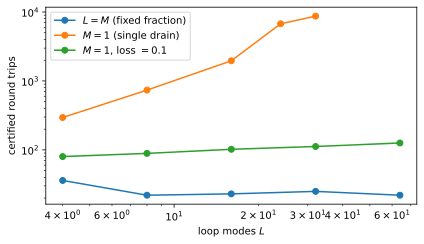

In [10]:
cases = {
    "$L = M$ (fixed fraction)": [
        (length, length, 0) for length in (4, 8, 16, 32, 64)],
    "$M = 1$ (single drain)": [
        (length, 1, 0) for length in (4, 8, 16, 24, 32)],
    "$M = 1$, loss $= 0.1$": [
        (length, 1, .1) for length in (4, 8, 16, 32, 64)],
}
figure, axis = plt.subplots(figsize=(6, 3.5))
for label, grid in cases.items():
    sizes, medians = [], []
    for length, external, loss in grid:
        sizes.append(length)
        medians.append(np.median([
            unroll_certificate(
                haar(length + external, seed), length,
                tol=1e-3, loss=loss)
            for seed in range(3)]))
    axis.loglog(sizes, medians, "o-", label=label)
    slope = np.polyfit(np.log(sizes[1:]), np.log(medians[1:]), 1)[0]
    print(f"{label}:  n = {[int(n) for n in medians]}"
          f"  (log-log slope {slope:.2f})")
axis.set_xlabel("loop modes $L$")
axis.set_ylabel("certified round trips")
axis.legend()
plt.tight_layout()
plt.show()

Polynomial in every regime, and better than polynomial in two of
them. At fixed loop fraction the certificate is **constant** in $L$: the
spectral radius of the block concentrates at $\sqrt{L/(L+M)}$, so
$\xi = O(1)$ and a few dozen round trips suffice at any size. The single
drain is the worst case and grows like $L^{1+1/M} = L^2$ — large, but
polynomial, and exactly the $\xi \sim L^{1+1/M}$ the notes predict: a
big loop is not a closed loop. Any damping flattens both to
$O(\delta^{-1}\log(\bar q L/\varepsilon))$ with **no condition on $U$
at all** — the singular values are capped by $(1-\delta)^{k/2}$
regardless of the geometry.

With the certified depth measured, the cost of *computing* the
certificate can now be stated in the inputs alone: $O(L^3)$ per step
gives $O(L^3)$ at fixed loop fraction, $O(L^{4+1/M})$ for the single
drain, and $O(L^3\,\delta^{-1}\log(\bar q L/\varepsilon))$ whenever
the singular values are damped below the loss rate — each a polynomial
in $L$ and $M$, where the simulation the certificate licenses is
exponential. A doubling search would cut the number of SVDs to
$O(\log n_{cert})$ at the price of a non-minimal certificate; the linear
scan keeps the smallest $k$, and at these polynomials it is never the
bottleneck.